## Клонирование репозитория и исправление путей

In [1]:
# Клонируем репозиторий
!git clone https://github.com/hj-n/labeled-datasets.git
%cd labeled-datasets

# Читаем оригинальный reader.py
with open("reader.py", "r") as f:
    content = f.read()

# Заменяем "/compressed/" на "compressed/"
content = content.replace('"/compressed/', '"compressed/')

# Записываем исправленный файл
with open("reader.py", "w") as f:
    f.write(content)

print("✅ reader.py исправлен. Проверяем ключевые строки:")
!grep -n "compressed" reader.py | head -10

Cloning into 'labeled-datasets'...
remote: Enumerating objects: 1129, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (226/226), done.
remote: Total 1129 (delta 16), reused 197 (delta 2), pack-reused 900 (from 1)
Receiving objects: 100% (1129/1129), 541.24 MiB | 24.07 MiB/s, done.
Resolving deltas: 100% (120/120), done.
Updating files: 100% (581/581), done.
/content/labeled-datasets
✅ reader.py исправлен. Проверяем ключевые строки:
14:	path = "./compressed/" + name + "/"
53:	names = os.listdir("./compressed/")


## Проверка списка датасетов

In [2]:
import os

dataset_dirs = sorted(os.listdir("compressed"))
print(f"Найдено {len(dataset_dirs)} датасетов в папке compressed/")
print("\nПолный список:")
for i, d in enumerate(dataset_dirs, 1):
    print(f"{i:3d}. 📁 {d}")

Найдено 193 датасетов в папке compressed/

Полный список:
  1. 📁 .DS_Store
  2. 📁 banknote_authentication
  3. 📁 banknote_authentication_bin.zip
  4. 📁 birds_bones_and_living_habits
  5. 📁 birds_bones_and_living_habits_bin.zip
  6. 📁 blood_transfusion_service_center
  7. 📁 blood_transfusion_service_center_bin.zip
  8. 📁 boston
  9. 📁 boston_bin.zip
 10. 📁 breast_cancer_coimbra
 11. 📁 breast_cancer_coimbra_bin.zip
 12. 📁 breast_cancer_wisconsin_original
 13. 📁 breast_cancer_wisconsin_original_bin.zip
 14. 📁 breast_cancer_wisconsin_prognostic
 15. 📁 breast_cancer_wisconsin_prognostic_bin.zip
 16. 📁 breast_tissue
 17. 📁 breast_tissue_bin.zip
 18. 📁 cardiovascular_study
 19. 📁 cardiovascular_study_bin.zip
 20. 📁 cifar10
 21. 📁 cifar10_bin.zip
 22. 📁 classification_in_asteroseismology
 23. 📁 classification_in_asteroseismology_bin.zip
 24. 📁 cnae9
 25. 📁 cnae9_bin.zip
 26. 📁 coil20
 27. 📁 coil20_bin.zip
 28. 📁 credit_risk_classification
 29. 📁 credit_risk_classification_bin.zip
 30. 📁 crowds

In [5]:
import os

compressed_dir = "compressed"
all_entries = sorted(os.listdir(compressed_dir))

# Фильтруем: только директории (не файлы), и внутри должны быть data.bin и label.bin
real_datasets = []
for entry in all_entries:
    entry_path = os.path.join(compressed_dir, entry)
    if os.path.isdir(entry_path):
        if os.path.exists(os.path.join(entry_path, "data.bin")) and \
           os.path.exists(os.path.join(entry_path, "label.bin")):
            real_datasets.append(entry)

print(f"Всего записей в compressed/: {len(all_entries)}")
print(f"Из них реальных датасетов: {len(real_datasets)}")
print("\nПолный список датасетов:")
for i, name in enumerate(real_datasets, 1):
    print(f"{i:3d}. 📁 {name}")

Всего записей в compressed/: 193
Из них реальных датасетов: 96

Полный список датасетов:
  1. 📁 banknote_authentication
  2. 📁 birds_bones_and_living_habits
  3. 📁 blood_transfusion_service_center
  4. 📁 boston
  5. 📁 breast_cancer_coimbra
  6. 📁 breast_cancer_wisconsin_original
  7. 📁 breast_cancer_wisconsin_prognostic
  8. 📁 breast_tissue
  9. 📁 cardiovascular_study
 10. 📁 cifar10
 11. 📁 classification_in_asteroseismology
 12. 📁 cnae9
 13. 📁 coil20
 14. 📁 credit_risk_classification
 15. 📁 crowdsourced_mapping
 16. 📁 customer_classification
 17. 📁 date_fruit
 18. 📁 dermatology
 19. 📁 diabetic_retinopathy_debrecen
 20. 📁 dry_bean
 21. 📁 durum_wheat_features
 22. 📁 echocardiogram
 23. 📁 ecoli
 24. 📁 epileptic_seizure_recognition
 25. 📁 extyaleb
 26. 📁 fashion_mnist
 27. 📁 fetal_health_classification
 28. 📁 flickr_material_database
 29. 📁 fraud_detection_bank
 30. 📁 glass_identification
 31. 📁 har
 32. 📁 harbermans_survival
 33. 📁 hate_speech
 34. 📁 heart_attack_analysis_prediction_datas

## Тест чтения одного датасета

In [3]:
import numpy as np
import reader as rd

# Тестируем на cifar10
try:
    data, label = rd.read_dataset("cifar10")
    print(f"✅ cifar10 загружен: data.shape={data.shape}, label.shape={label.shape}")
except Exception as e:
    print(f"❌ Ошибка при загрузке cifar10: {e}")

✅ cifar10 загружен: data.shape=(3250, 1024), label.shape=(3250,)


## Пакетная загрузка всех датасетов + полная статистика

In [6]:
import os, numpy as np
import reader as rd
import zlib

# Загрузим все датасеты из отфильтрованного списка
data_dict, label_dict = rd.read_multiple_datasets(real_datasets)

# Базовая статистика
rows = []
for name in sorted(data_dict.keys()):
    X = data_dict[name]
    y = label_dict[name]
    rows.append({
        'dataset': name,
        'n_samples': X.shape[0],
        'n_features': X.shape[1],
        'n_classes': len(np.unique(y)),
        'ratio': round(X.shape[0] / X.shape[1], 2) if X.shape[1] > 0 else float('inf')
    })

import pandas as pd
df = pd.DataFrame(rows)
print(f"Загружено {len(df)} датасетов")
df.to_csv('dataset_summary.csv', index=False)
print("✅ Сохранено в dataset_summary.csv")

# Показать все строки
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df.to_string())

Загружено 96 датасетов
✅ Сохранено в dataset_summary.csv
                                        dataset  n_samples  n_features  n_classes    ratio
0                       banknote_authentication       1372           4          2   343.00
1                 birds_bones_and_living_habits        413          10          6    41.30
2              blood_transfusion_service_center        748           4          2   187.00
3                                        boston        154          13          3    11.85
4                         breast_cancer_coimbra        116           9          2    12.89
5              breast_cancer_wisconsin_original        683           9          2    75.89
6            breast_cancer_wisconsin_prognostic        569          30          2    18.97
7                                 breast_tissue        106           9          6    11.78
8                          cardiovascular_study       2927          15          2   195.13
9                                

## EDA-графики

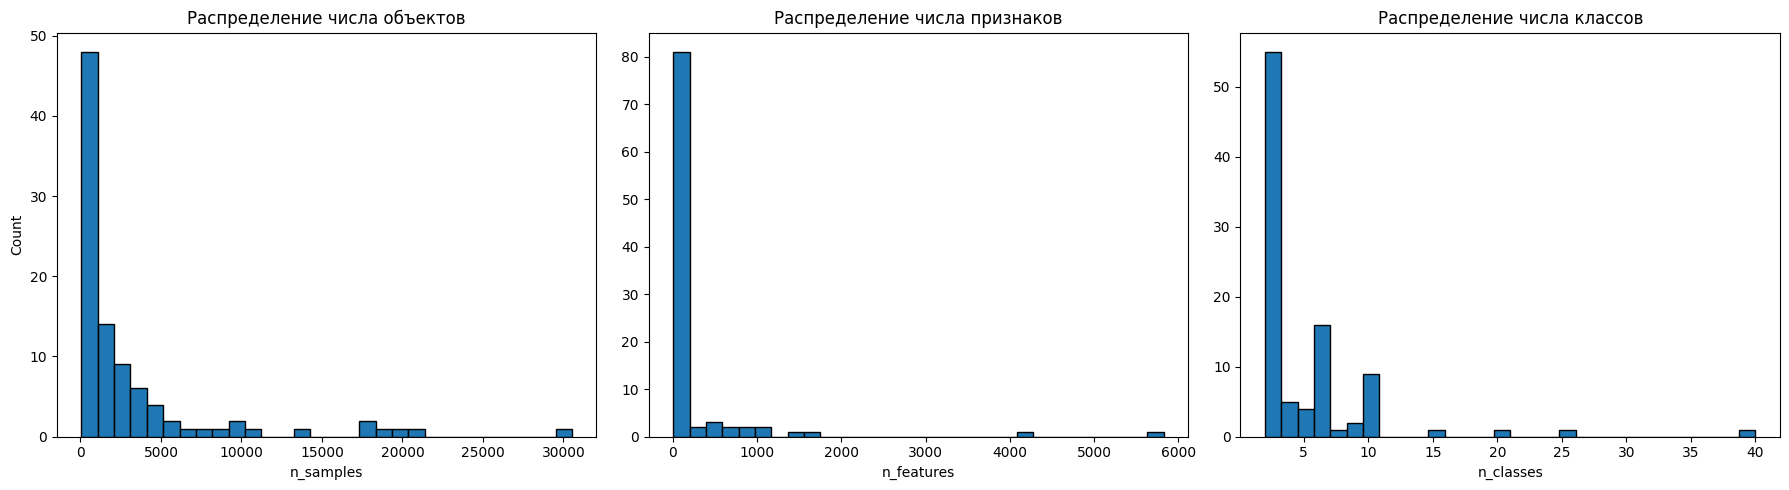

✅ Графики сохранены в eda_distributions.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Распределение n_samples
axes[0].hist(df['n_samples'], bins=30, edgecolor='black')
axes[0].set_xlabel('n_samples')
axes[0].set_ylabel('Count')
axes[0].set_title('Распределение числа объектов')

# Распределение n_features
axes[1].hist(df['n_features'], bins=30, edgecolor='black')
axes[1].set_xlabel('n_features')
axes[1].set_title('Распределение числа признаков')

# Распределение n_classes
axes[2].hist(df['n_classes'], bins=30, edgecolor='black')
axes[2].set_xlabel('n_classes')
axes[2].set_title('Распределение числа классов')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()
print("✅ Графики сохранены в eda_distributions.png")

## Дополнительные EDA-метрики (только для датасетов ≤ 1M элементов)

In [9]:
from scipy.stats import skew, kurtosis

extra_rows = []
for name in sorted(data_dict.keys()):
    X = data_dict[name]
    if X.shape[0] * X.shape[1] < 1_000_000:
        flat = X.flatten()
        extra_rows.append({
            'dataset': name,
            'mean': np.mean(flat),
            'std': np.std(flat),
            'skewness': skew(flat),
            'kurtosis': kurtosis(flat)
        })

extra_df = pd.DataFrame(extra_rows)
extra_df.to_csv('dataset_extra_stats.csv', index=False)
print(f"✅ Дополнительные статистики сохранены для {len(extra_df)} датасетов (размер ≤ 1M элементов)")
# Вывести их все
with pd.option_context('display.max_rows', None):
    print(extra_df.to_string())

✅ Дополнительные статистики сохранены для 86 датасетов (размер ≤ 1M элементов)
                                        dataset          mean           std    skewness      kurtosis
0                       banknote_authentication  6.405147e-01  4.215620e+00    0.454617      1.078385
1                 birds_bones_and_living_habits  2.921569e+01  4.047069e+01    2.765485     12.000184
2              blood_transfusion_service_center  3.569950e+02  9.382432e+02    5.272892     42.199699
3                                        boston  7.059882e+01  2.217642e+02    4.084002     17.221696
4                         breast_cancer_coimbra  8.683921e+01  1.979923e+02    4.354514     23.195834
5              breast_cancer_wisconsin_original  3.148365e+00  2.894903e+00    1.278864      0.340246
6            breast_cancer_wisconsin_prognostic  6.189071e+01  2.282974e+02    6.107600     49.681046
7                                 breast_tissue  1.042935e+03  6.570509e+03   20.377201    511.464133
8  